In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split


from qae_qknn import QAEConfig, QuantumAutoencoder
from preprocessing import timed_preprocess

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, Sampler, Session

service = QiskitRuntimeService(
    channel="ibm_quantum_platform", 
    token="token",
    instance="crn"
)

backend = service.backend("ibm_marrakesh")

In [8]:
prep = timed_preprocess(percent10=True, n_components=4, vis_samples=1000)

X_train = prep["X_train_pca"]
X_test = prep["X_test_pca"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)

KDD99 preprocessing time: 13.14s
Full train: (155644, 4)
Full test:  (98805, 4)


In [ ]:
X_train_qae_full, X_val_qae, y_train_qae_full, y_val_qae = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

rng = np.random.default_rng(42)

# Larger numbers can be chosen if the training is not run on IBM.
train_subset_size = 40
train_idx = rng.choice(len(X_train_qae_full), size=train_subset_size, replace=False)
X_train_qae = X_train_qae_full[train_idx]
y_train_qae = y_train_qae_full[train_idx]

val_subset_size = 10 
val_idx = rng.choice(len(X_val_qae), size=val_subset_size, replace=False)
X_val_qae_small = X_val_qae[val_idx]
y_val_qae_small = y_val_qae[val_idx]

print("QAE train subset:", X_train_qae.shape)
print("QAE val subset:  ", X_val_qae_small.shape)

QAE train subset: (40, 4)
QAE val subset:   (10, 4)


In [ ]:
config = QAEConfig(
    n_qubits=4,
    n_latent=2,
    n_layers=1,
    seed=42,
    use_swap_test_loss=True,
    use_log_cost=True,
)
# If the training is not run on IBM, set backend to None
# If running on IBM, in qae.py, set number of shots to 128
qae = QuantumAutoencoder(config, backend=backend)

best_params, history, scaler = qae.train(
    X_train_raw=X_train_qae,
    X_val_raw=X_val_qae_small,
    steps=3,  # Can use more steps if not run on IBM
    lr=0.03,
    batch_size=4, # Can use larger batch size if not run on IBM
    val_every=10, 
    verbose=True,
)

/Users/nicoletadobrica/AQA_QDL/venv/lib/python3.13/site-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[Step 000] train_loss=-0.057992 | val_loss=-0.025863
[Step 002] train_loss=-0.069783 | val_loss=-0.020850


In [11]:
qae.save_checkpoint(
    "qae_checkpoint.npz",
    params=best_params,
    scaler=scaler,
    history=history,
    extra_metadata={"dataset": "KDDCup99 PCA-4"}
)

In [ ]:
# Leftover from previous implementation, actual values set later
qknn_train_size = 2000
qknn_test_size = 400

train_idx_small = rng.choice(len(X_train), size=qknn_train_size, replace=False)
test_idx_small = rng.choice(len(X_test), size=qknn_test_size, replace=False)

X_train_small = X_train[train_idx_small]
y_train_small = y_train[train_idx_small]

X_test_small = X_test[test_idx_small]
y_test_small = y_test[test_idx_small]

In [ ]:
# Small numbers necessary for IBM
qknn_test_n = 20
qknn_train_n = 30
qae_local = QuantumAutoencoder(config, backend=None) 

print("Compressing datasets using trained QAE...")
y_tr_labels = y_train_small[:qknn_train_n]
y_te_true = y_test_small[:qknn_test_n]

X_train_latent = qae_local.batch_transform_latent_features_from_raw(
    X_train_small[:qknn_train_n], best_params, scaler, verbose=False
)

X_test_latent = qae_local.batch_transform_latent_features_from_raw(
    X_test_small[:qknn_test_n], best_params, scaler, verbose=False
)

X_train_states_raw = qae_local.get_all_latent_states(
    X_train_small[:qknn_train_n], best_params, scaler
)

X_test_states_raw = qae_local.get_all_latent_states(
    X_test_small[:qknn_test_n], best_params, scaler
)


print(f"Original shape: {X_train_small[:qknn_train_n].shape}") 
print(f"Latent shape:   {X_train_latent.shape}")  

Compressing datasets using trained QAE...
Original shape: (2000, 4)
Latent shape:   (30, 2)


In [15]:
from collections import Counter
def qknn_predict(fidelity_matrix, y_train, k=3):
    y_pred = []
    y_prob = []

    for row in fidelity_matrix:
        idx = np.argsort(row)[-k:]
        labels = y_train[idx]

        y_pred.append(Counter(labels).most_common(1)[0][0])
        y_prob.append(np.mean(labels))

    return np.array(y_pred), np.array(y_prob)

In [ ]:
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister
from qiskit_ibm_runtime import SamplerV2 as Sampler
import numpy as np

print("Extracting complex latent state vectors...")

X_train_states = [np.array(s, dtype=complex) for s in X_train_states_raw]
X_test_states = [np.array(s, dtype=complex) for s in X_test_states_raw]
pairs = []
for xt in X_test_states:
    for xr in X_train_states:
        pairs.append((xt, xr))

n_pairs = len(pairs)
print(f"Building {n_pairs} SWAP-test circuits for IBM...")

circuits = []
for i in range(n_pairs):
    qr = QuantumRegister(5, name='q')
    cr = ClassicalRegister(1, name='meas')
    qc = QuantumCircuit(qr, cr)
    
    state_test = pairs[i][0]
    state_train = pairs[i][1]
    
    qc.prepare_state(state_test, [1, 2])  # Register 1
    qc.prepare_state(state_train, [3, 4]) # Register 2
    
    qc.h(0)
    qc.cswap(0, 1, 3)
    qc.cswap(0, 2, 4)
    qc.h(0)
    
    qc.measure(0, 0)
    circuits.append(qc)

print(f"Transpiling for {backend.name}...")
transpiled_circuits = transpile(circuits, backend=backend, optimization_level=1)
sampler = Sampler(mode=backend)
print(f"Submitting Job (ID will appear once uploaded)...")
job = sampler.run(transpiled_circuits, shots=2048)
print(f"Job ID: {job.job_id()}")
print("Waiting for results from IBM...")
result = job.result()

fidelities = []
for i in range(n_pairs):
    pub_result = result[i]
    counts = pub_result.data.meas.get_counts()
    zeros = counts.get('0', 0)
    p0 = zeros / 2048
    f = np.clip(2 * p0 - 1, 0.0, 1.0)
    fidelities.append(f)

F = np.array(fidelities).reshape(qknn_test_n, qknn_train_n)

y_pred_qknn, y_prob_qknn = qknn_predict(F, y_tr_labels, k=3)

Extracting complex latent state vectors...
Building 600 SWAP-test circuits for IBM...
Transpiling for ibm_marrakesh...
Submitting Job (ID will appear once uploaded)...
Job ID: d7a6rujc6das739jovm0
Waiting for results from IBM...



Accuracy: 0.8500 | ROC-AUC: 0.9000


,precision,recall,f1-score,support
normal,0.6250,1.00,0.7692,5.00
attack,1.0000,0.80,0.8889,15.00
accuracy,0.8500,0.85,0.8500,0.85
macro avg,0.8125,0.90,0.8291,20.00
weighted avg,0.9062,0.85,0.8590,20.00


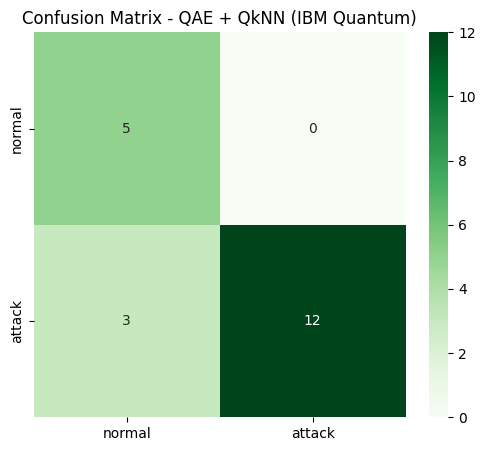

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)

y_te_true_int = np.array(y_te_true, dtype=int)
y_pred_qknn_int = np.array(y_pred_qknn, dtype=int)

acc_qknn = accuracy_score(y_te_true_int, y_pred_qknn_int)
auc_qknn = roc_auc_score(y_te_true_int, y_prob_qknn)
cm_qknn = confusion_matrix(y_te_true_int, y_pred_qknn_int)

report_qknn = pd.DataFrame(classification_report(
    y_te_true_int,
    y_pred_qknn_int,
    target_names=["normal", "attack"],
    output_dict=True
)).T

print(f"\nAccuracy: {acc_qknn:.4f} | ROC-AUC: {auc_qknn:.4f}")
display(report_qknn.round(4))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_qknn, annot=True, fmt="d", cmap="Greens",
            xticklabels=["normal", "attack"],
            yticklabels=["normal", "attack"])
plt.title("Confusion Matrix - QAE + QkNN (IBM Quantum)")
plt.show()

